<a href="https://colab.research.google.com/github/cathdong66-lgtm/EMSC2010-W9-Group-Project/blob/main/EMSC2010_Group_Project_WK9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project Week 9

## 1. Project Overview
Group name: Cloudy with a chance of stats

Project week: 9

Project title: How does Earth's surface temperature change with increasing CO2 emissions?

Datasets used (name and source): NA

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Deadline |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Cathy | Sutton | Yes| 8/5|
| Data steward | Sutton | Leo | Yes| 9/5|
| Analysis / modelling | Leo | Elena | Yes| 11/5|
| Visualisation / interpretation | Elena | Kimi | Yes| 12/5|
| Narrative | Kimi | Sameer | Yes| 13/5|
| Quality Control / Reproducibility  | Sameer | Cathy | Yes| 14/5|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Project Overview**

This week, our group decided to tackle the question of "How does Earth's surface temperature change with increasing CO2 emissions?". We thought that this question would best represent our understanding of numercial simulation and modelling. Using our knowledge from this week, we plotted how different atmospheric temperatures with changing CO2 concentrations would change the surface temperature. Additonally, we also plotted how surface temperature changes with time. Both of these plots aim to simulate real world phenomena in a way that can be anaylsed. Although simplified, having such knowledge allows for us to understand what the effects of climate change might be as we continue to increase CO2 emissions.

**Data Analysis/Modelling**


Not much data was required for this question, thus values for the earths energy balance model and its constants were derived from the internet. Our initial conditions were set to preindustrial levels for both CO2 and temperature, with CO2 being 280ppm and 286K for the preindustrial global surface temperature. To answer the question of how earths surface temperature changes with increasing CO2 emissions, we employed a numerical model spanning over 300 years and 10 different emission pathways. Within the different scenarios, we started at -3ppm/year and increased by 1ppm until we reached +6ppm/year. This model runs each scenario from the preindustrial level until we reach 300 years to see how temperature changes with CO2 concentrations and with time.



Model adapted from Myhre,G. (1998) *New Estimates of Radiate Forcing due to Well MIxed Greenhouse Gases*, AGU. https://doi.org/10.1029%2F98GL01908

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
σ =  5.67*10**-8 #Stefan-boltzman constant (W*m**-2*K**-4)
α = 0.3 #Albedo
S = 1360 #Solar flux (W/m^2)
T0 = ((S*(1-α)/4)/σ)**0.25 #Surface temperature without atmosphere (K)

In [ ]:
T0

254.53556605545324

In [ ]:
#C0 = 280 #Preindustrial CO2 level (ppm)
#T0 = 286 # Preindustrial Global Surface Temperature
#F = 5.35*np.log(C/C0) #Radiative forcing (W/m^2) - From Myhre 1998
#λ = 0.8 #Climate sensitivy parameter (K/(W/m^2))
#T_c = λ*F #Temperature increase from CO2
#T_a = T0 + T_c #Temp with atmosphere

In [ ]:
# Initialise time step
years = 300 # Length of simulation
nsteps = years # Number of time steps

# Initialise CO2 growth rate and range
growth_rate_range = 10
growth_rate_min = -3 # Minimum growth rate (ppm/year)

# Initialise other constants
C0 = 280 #Preindustrial CO2 level (ppm)
λ = 0.8 #Climate sensitivy parameter (K/(W/m^2))

In [ ]:
# Initialise arrays to store simulation results for each growth rate and time step.
# C: CO2 concentration (ppm)
# F: Radiative forcing (W/m^2)
# T_C: Temperature change due to CO2 (K)
# T_a: Total atmospheric temperature (K)
# Each array is (growth_rate_range x nsteps) to store data for all scenarios.
C = np.zeros((growth_rate_range, nsteps))
F = np.zeros((growth_rate_range, nsteps))
T_C = np.zeros((growth_rate_range, nsteps))
T_a = np.zeros((growth_rate_range, nsteps))

# Create a time array from 0 to nsteps-1, representing years.
time = np.arange(nsteps)

# Define the range of CO2 growth rates to simulate
growth_rates = np.arange(growth_rate_min, growth_rate_min + growth_rate_range)

# Main simulation loop: Iterate through each defined CO2 growth rate scenario.
for i in range(growth_rate_range):
  current_growth_rate = growth_rates[i]

  # Set initial CO2 concentration for the current growth rate scenario at time step 0.
  # C0 is the preindustrial CO2 level.
  C[i, 0] = C0
  # Set initial atmospheric temperature for the current growth rate scenario at time step 0.
  # This uses the predefined preindustrial global surface temperature T0.
  T_a[i, 0] = T0

  # Inner loop: Iterate through each time step for the current growth rate scenario.
  # The loop starts from j=1 because j=0 has been set as the initial condition.
  for j in range(1, nsteps):
    # Calculate CO2 concentration for the current step based on the previous step and the current growth rate.
    C[i, j] = C[i, j-1] + current_growth_rate
    # Ensure atmospheric CO2 does not drop below 1 ppm (to prevent errors with log and for realism).
    if C[i, j] < 1:
       C[i, j] = 1
    # Calculate radiative forcing using Myhre 1998 formula.
    # F = 5.35 * ln(C/C0)
    F[i, j] = 5.35 * np.log(C[i, j] / C0)
    # Calculate the temperature change due to CO2 using the climate sensitivity parameter (λ).
    T_C[i, j] = λ * F[i, j]
    # Calculate the total atmospheric temperature for the current step.
    T_a[i, j] = T0 + T_C[i, j]

## After writing the code and key annotations in this cell I asked Gemini to annotate it.
## It expanded on my key annotations and suggested comments on the rest of, which I read over and approved.

**Data Interpretation & Visualization**

For the visualisation and data interpretation, we were able to plot two graphs, one visualising the atmospheric temperature over time for different growth rates (left) and the temperature change due to CO2 over time (right). We were able to do this by creating two subplot axes within the same figure and placing plotting commands inside the simulation loop, this was done so that they would similtaneously plot the corresponding temeprature data as the loop iterated through each CO2 growth-rate scnario.

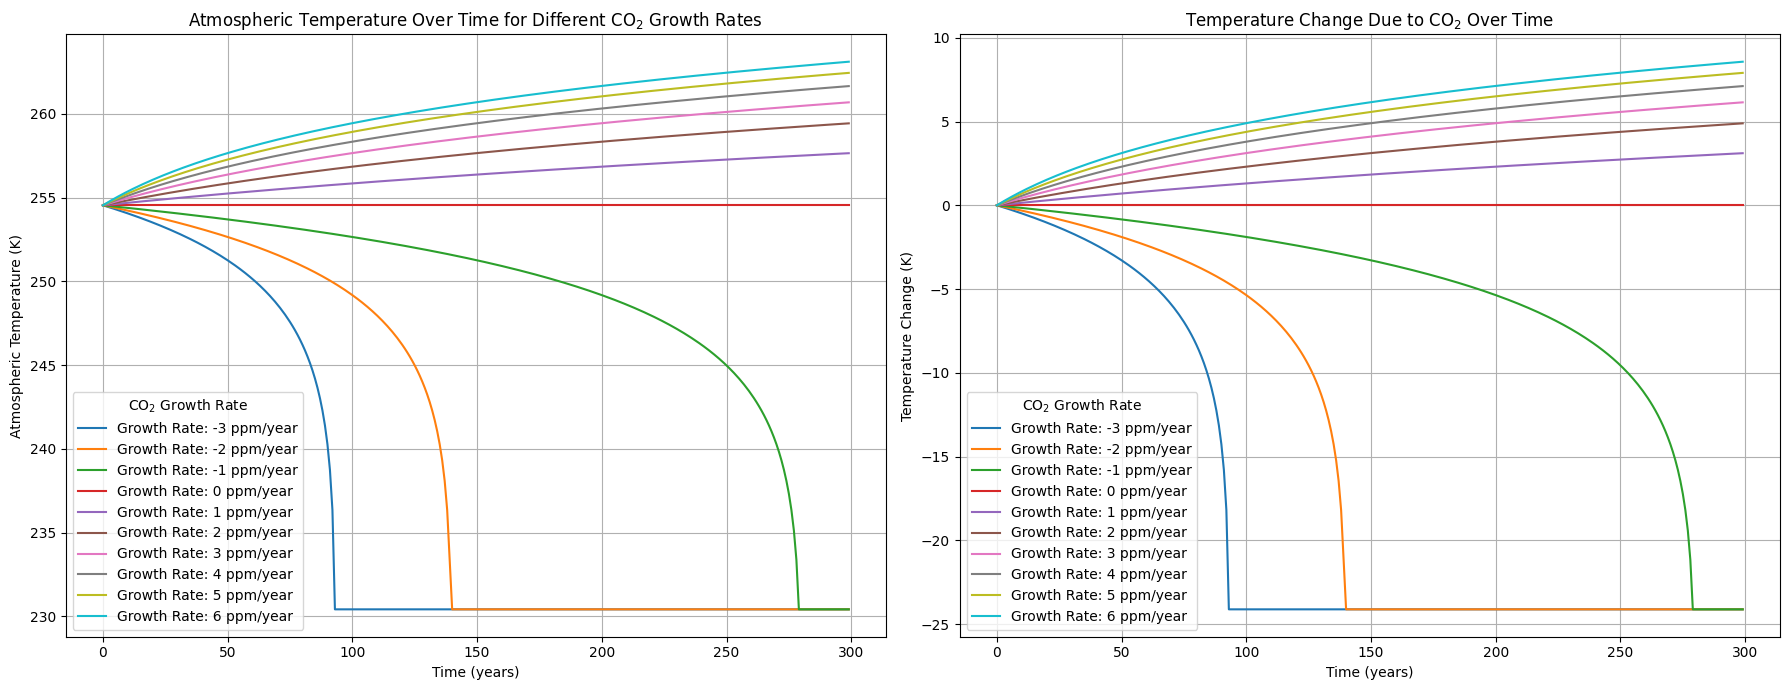

In [ ]:
fig, ax= plt.subplots(1, 2, figsize=(18, 7), sharex=True)

for i in range(growth_rate_range):
  # Plot atmospheric temperature
  ax[0].plot(time, T_a[i], label=f'Growth Rate: {growth_rates[i]} ppm/year')
  # Plot temperature change due to CO2
  ax[1].plot(time, T_C[i], label=f'Growth Rate: {growth_rates[i]} ppm/year')

# Customize the first subplot (Atmospheric Temperature)
ax[0].set_title(r'Atmospheric Temperature Over Time for Different CO$_2$ Growth Rates')
ax[0].set_xlabel('Time (years)')
ax[0].set_ylabel('Atmospheric Temperature (K)')
ax[0].legend(title=r'CO$_2$ Growth Rate')
ax[0].grid(True)

# Customize the second subplot (Temperature Change due to CO2)
ax[1].set_title(r'Temperature Change Due to CO$_2$ Over Time')
ax[1].set_xlabel('Time (years)')
ax[1].set_ylabel('Temperature Change (K)')
ax[1].legend(title=r'CO$_2$ Growth Rate')
ax[1].grid(True)

plt.tight_layout()
plt.show()

**Interpretation**

From these two graphs we can see the difference changing the intial parameters of the simulation makes. The difference between each graph is what the initial CO2 Growth rate is, and this changes how much temperature changes over time. When CO2 in the atmosphere is decreasing, this causes temperature to decrease over time, until it flatlines at around 230K. Conversely, increasing CO2 in the atmosphere increases the greenhouse effect, which means less of the sun's radiation escapes the atmosphere, causing a warmer atmospheric temperature, and a higher ΔT.

These results can give us real-world implications, telling us the nature and sensitivity of the climate system. This numerical simulation tells us that even a small amount of change in CO2 cocentrations can cause a response in the climate system, which may reflect a simple yet insightful understanding of the current climate sitation. Overall these results imply demonstrate that earths surface and atmospheric temperatures are highly dependent on future emission pathways

# **Reflections**

**Cathy**

This week I was responsible for setting up the group GitHub repository and colab. This meant I polished up the project overview, roles and contributions and reflections, as well as clean up the repository such as removing the inital group project template after I made the final commit to GitHub. There was an error on my part when it came to initially sharing the colab link with the incorrect permissions to edit. I rectified this in time so Leo had enough time to do his part before his deadline. Doing this role has solidified by skills on how to create a colab that can be edited on by other people, as well as cleaning the repository to make it presentable for viewing.

**Sutton**


This week I had the role of data steward where I had to research and find a simple one atmosphere climate model as well as the model parameters to use. Our aim was to model the effect of carbon dioxide radiative forcing upon the global surface temperature. After some research I found a model and parameters in a paper by Myhre,G frtom 1998 and adapted it to todays conditions. This week allowed me to learn how I can find pre-developed models and adapt them easily to solve related problems.

**Leo**

In my role as analysis/modelling lead this week, I took the formula and constants provided by Sutton and utilised a loop to implement a model over time. This predicted temperature over a time period accounting for a constant increase of CO2. I decided this was a bit simple and added an further step to the code, implementing the model over a range of increasing rates of CO2. This presented a couple of additional challenges: I had to make the arrays to store the values two dimensional to accomodate running the model multiple times under different CO2 forcings and with the addition of a negative CO2 emissions rate, I had to introduce an if statement to ensure that total atmospheric CO2 did not drop below 1ppm and break the formula (which included a log(CO2)).

**Elena**

This week as the person in charge of visualisation and interpretation, I was able to effectively communicate with my team members about how best to display this information. There was a slight glitch with the whole document not running, but through quick communication this issue was resolved. The trickiest part was figuring out how to account for the different levels of CO2, but through simple array indexing and a for loop, I was able to implement this improvement made by Leo. Part of the job was also cleaning up the graphs' titles, axes, and labels, which I had to delve back through the weeks of learning to achieve. These graphs are not perfect real-world models, but can give us a good start into investigating how one element can affect atmospheric temperature.

**Kimi**

This week, my role of narrative required me to peice each of the parts together through giving a worded summary of each of the components of the colab notebook. I found this quite insightful as it required me to truly understand the question that we were answering and the code that went into producing the outputs, of which none of my previous roles had done yet. This role was made easy from the comments and annotations of those that were in the data analysis and visualisation roles. Narrative's in the preivous colab notebooks provided a helpful idea of what was required of me to write in this section. I found that this weeks questions was quite straightforward and easy to link to real world implications. Overall, this weeks group project provided me with a deeper understanding of numercial modelling and how it can help us understand real world scenarios in a somewhat simplified way.

**Sameer**

As the Quality Control / Reproducibility Lead, my primary focus this week was to ensure the integrity and clarity of our project notebook. This involved meticulously checking that the entire notebook could run seamlessly from top to bottom without any errors, which included verifying all code cells executed correctly and in the intended sequence. I reviewed the generated figures and outputs to confirm they accurately represented the data and analysis, and that their presentation was clear and insightful.This role provided valuable experience in the critical importance of meticulous review and clear communication in scientific projects.